In [1]:
import numpy as np
import pybullet as p
import pybullet_data
import time
import os
import matplotlib.pyplot as plt

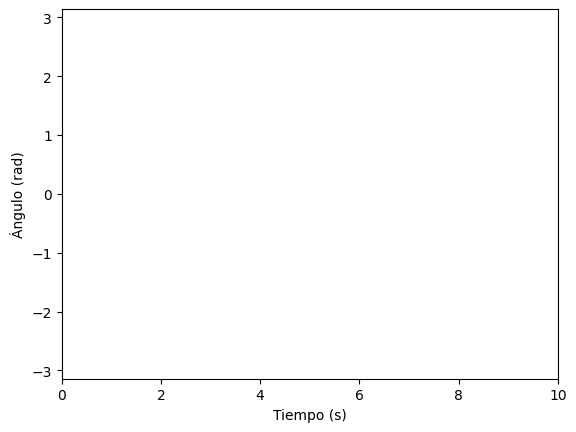

In [2]:
p.connect(p.GUI)
p.resetSimulation()
p.setAdditionalSearchPath(pybullet_data.getDataPath())

p.setGravity(0,0,-9.8)
p.setRealTimeSimulation(0)


p.loadURDF("plane.urdf", [0,0,0], [0,0,0,1])
pendulum = p.loadURDF("twowheel.urdf", [0,0,0.15], [0,0,0,1])

plt.ion()  # Activar modo interactivo
fig, ax = plt.subplots()
times, angles = [], []
line, = ax.plot(times, angles, 'b-')  # Línea para el ángulo
ax.set_ylim(-np.pi, np.pi)
ax.set_xlim(0, 10)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Ángulo (rad)')

obj_of_focus = pendulum


In [3]:
joint_left = p.getJointInfo(pendulum, 1)
joint_right = p.getJointInfo(pendulum, 2)


jlower = joint_left[8]
jupper = joint_left[9]

print(jlower, jupper)

0.0 6.28


In [4]:
p.getJointInfo(pendulum, 1)

(1,
 b'l_join',
 0,
 8,
 7,
 1,
 0.0,
 0.0,
 0.0,
 6.28,
 100.0,
 720.0,
 b'l_wheel',
 (3.4641020661939353e-07, -3.4641020661937267e-07, 0.9999999999998799),
 (-0.09500001732049893, -1.5588470697874738e-08, -0.04999996709103577),
 (-2.449489661487456e-07,
  0.7071066656470094,
  2.449490510015677e-07,
  0.7071068967259817),
 -1)

In [5]:
joint_left[8]

0.0

In [18]:
p.getLinkState(pendulum, 0, computeForwardKinematics=True, computeLinkVelocity=True)

((0.013724829461349064, -0.09946386002801028, 0.10109246986204282),
 (0.32830757783410475,
  0.6254591526077358,
  -0.42512780767103225,
  0.5659340331705969),
 (0.0, 0.0, 0.05),
 (-1.7320513330970198e-07,
  -1.7320507330968636e-07,
  -1.7320513330970198e-07,
  0.9999999999999549),
 (-0.007714747451245785, -0.05429380014538765, 0.10099098831415176),
 (0.3283078372478485,
  0.6254590749740601,
  -0.4251277446746826,
  0.5659340023994446),
 (-0.05684648993614626, -0.04090379194287432, 0.09119194724682243),
 (-5.61080596216067, 10.954021932948137, -0.954695284992306))

In [21]:
for step in range(500):
    joint_two_targ = np.random.uniform(jlower, jupper)
    joint_four_targ = np.random.uniform(jlower, jupper)
    p.setJointMotorControlArray(pendulum, [0, 1], p.VELOCITY_CONTROL, targetVelocities=[10, 10])
    p.stepSimulation()
    time.sleep(.01)
    print(p.getJointStates(pendulum, [0, 1]))

((45.43203017637422, 10.000076445898625, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), 0.6050002142014458), (3.6106541242175156, 9.999894819606462, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), 26.109300646510174))
((45.473697274355594, 10.0001035155297, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), -0.31743379307367947), (3.6523204771038227, 9.999924692713696, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), 0.41873588852825605))
((45.515364437499684, 10.000119154581808, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), -0.22429063933607024), (3.693986873440985, 9.999935120918973, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), 0.7488535659484186))
((45.557031631080406, 10.000126459373027, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), -0.18373808760346824), (3.735653285173863, 9.999938815890694, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), 0.8583889193113793))
((45.59869873519851, 10.00010498834507, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), -0.3153104530192803), (3.7773196333887915, 9.999923571582876, (0.0, 0.0, 0.0, 0.0, 0.0, 0.0), 0.4162514847880498))
((45.640365848787184, 10.000107261281563, (0.0, 0.0, 0.0, 0

In [2]:
import numpy as np
import pybullet as p
import pybullet_data
import time
import gymnasium as gym
import math

In [404]:
class CarPendulumEnv(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps":4}
    def __init__(self, render_mode="human", size=5):
        self.state = self.init_state()
        self.step_count = 0

    def init_state(self):
        p.connect(p.GUI)
        p.resetSimulation()
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0,0,-9.81)
        p.setRealTimeSimulation(0)

        self.angle_slider = p.addUserDebugParameter("Angle", -np.deg2rad(5), np.deg2rad(5), 0)

        p.loadURDF("plane.urdf", [0,0,0], [0,0,0,1])
        self.pendulum = p.loadURDF("twowheel.urdf", [0,0,0.05], [0,0,0,1])

        focus_position, _ = p.getBasePositionAndOrientation(self.pendulum)
        p.resetDebugVisualizerCamera(cameraDistance=3, cameraYaw=90, cameraPitch=-40, cameraTargetPosition = focus_position)

        #self.pendulum = p.loadURDF("./Proyecto/InvertedPendulum/twowheel.urdf", [0,0,0.15], [0,0,0,1])
        # id=0 - r_wheel
        # id=1 - l_wheel
        right_wheel_speed = p.getLinkState(self.pendulum, 0, computeForwardKinematics=True, computeLinkVelocity=True)[7]
        left_wheel_speed = p.getLinkState(self.pendulum, 1, computeForwardKinematics=True, computeLinkVelocity=True)[7]
        _, orientation_quat = p.getBasePositionAndOrientation(self.pendulum)
        orientation_euler = p.getEulerFromQuaternion(orientation_quat)

        obs = {
            "r_speed": right_wheel_speed,
            "l_speed": left_wheel_speed,
            "pendulum_angle": orientation_euler[0]
        }
        return obs
    
    def reset(self):
        p.disconnect()
        self.state = self.init_state()
        self.step_count = 0


    def step(self, action):

        self.step_count += 1

        target = p.readUserDebugParameter(self.angle_slider)
        print(target)

        p.stepSimulation()

        u = self.getConstants(target)
        print(u)
        p.setJointMotorControlArray(self.pendulum, [0,1], p.TORQUE_CONTROL, forces=[u, -u])
        focus_position, _ = p.getBasePositionAndOrientation(self.pendulum)
        p.resetDebugVisualizerCamera(cameraDistance=3, cameraYaw=90, cameraPitch=-40, cameraTargetPosition = focus_position)
        
        right_wheel_speed = p.getLinkState(self.pendulum, 0, computeForwardKinematics=True, computeLinkVelocity=True)[7]
        left_wheel_speed = p.getLinkState(self.pendulum, 1, computeForwardKinematics=True, computeLinkVelocity=True)[7]        

        _, orientation_quat = p.getBasePositionAndOrientation(self.pendulum)
        orientation_euler = p.getEulerFromQuaternion(orientation_quat)

        done = False

        if(self.step_count >= 100000):
            self.reset()
            reward = 0
            done = True

        obs = {
            "r_speed": right_wheel_speed,
            "l_speed": left_wheel_speed,
            "pendulum_angle": orientation_euler[0]
        }

        self.state = obs

        
        reward = -abs(target-orientation_euler[0])

        return obs, reward, done, False, {"target":target}
    

    def getConstants(self, target):
        wheel_mass = 2
        pendulum_mass = 4
        a = 0.2
        g = 9.81
        l = 0.3
        wheel_r = 0.1

        wheel_speed = p.getLinkState(self.pendulum, 1, computeForwardKinematics=True, computeLinkVelocity=True)[7][0]

        _, orientation_quat = p.getBasePositionAndOrientation(self.pendulum)
        theta = p.getEulerFromQuaternion(orientation_quat)[0]

        wheel_position_quat = p.getLinkState(self.pendulum, 1, computeForwardKinematics=True, computeLinkVelocity=True)[1]        
        wheel_position = p.getEulerFromQuaternion(wheel_position_quat)[1] + np.pi/2

        dtheta = p.getLinkState(self.pendulum, 2, computeForwardKinematics=True, computeLinkVelocity=True)[7][0]
        
        # print("wheel: " + str(wheel_position))
        # print("pendulum: "+ str(theta))
        # print("wheel_s: " + str(wheel_speed))
        # print("pendulum_s: "+ str(dtheta))

        kp1 = 8000
        kp2 = 30
        kd1 = 180
        kd2 = 30
        #print("target: "+str(target))
        u = kp1*(theta-target) + kp2*wheel_position + kd1*dtheta + kd2*wheel_speed

        # A = np.asarray([
        #     [pendulum_mass*(a**2+(l**2)/2), pendulum_mass*a*wheel_r*np.cos(theta)],
        #     [pendulum_mass*a*wheel_r*np.cos(theta), (pendulum_mass+3/2*wheel_mass)*wheel_r**2]
        # ])

        # B = np.asarray([
        #     [pendulum_mass*a*g*np.sin(theta)-u], 
        #     [pendulum_mass*a*wheel_r*dtheta*np.sin(theta)+u]
        # ])

        return u

    def stop(self):
        p.disconnect()

In [405]:
env = CarPendulumEnv()

In [403]:
env.stop()

In [ ]:
env.pendulum

1

In [16]:
env.getConstants()

(b'robot_base', b'chasis')


In [406]:
while True:
    env.step(10)
    time.sleep(.01)

0.0
-0.0027745176365323613
0.0
-0.0027813768564961486
0.0
-0.0027984204158908793
0.0
-0.002772381821574118
0.0
-0.002789534787402638
0.0
-0.002764395108222094
0.0
-0.002782510670846572
0.0
-0.002758444582523788
0.0
-0.0027775221171186144
0.0
-0.0027544940246307255
0.0
-0.0027745293894960305
0.0
-0.0027525048935482374
0.0
-0.002773496006135347
0.0
-0.0027524437886537697
0.0
-0.0027743906677433336
0.0
-0.002779812617920017
0.0
-0.0027863606740133537
0.0
-0.0027934310589809615
0.0
-0.002800981059542085
0.0
-0.0028090080790381397
0.0
-0.0028175125498723723
0.0
-0.002826495267456618
0.0
-0.002835957490187579
0.0
-0.0028459006955326147
0.0
-0.002856326632548048
0.0
-0.0028672373038825354
0.0
-0.002878635092928013
0.0
-0.0028905225354405864
0.0
-0.002902902590200058
0.0
-0.002915778421566616
0.0
-0.0029291534611193912
0.0
-0.0029430315106617633
0.0
-0.002957416587185917
0.0
-0.0029723130517861516
0.0
-0.0029877255331098563
0.0
-0.00300365895988242
0.0
-0.003020118551257505
0.0
-0.003037109841

KeyboardInterrupt: 